## 5.1知识引入
AA 制记账
**场景**：好朋友一起出去玩，各种情况下可能有人垫付了一部分钱，但最终总花费得请大家均分。我们需要：
-  添加参与者：将新的朋友名字添加到系统中，并初始化其余额为 0。
-  记录支出：如果某个人帮大家垫付了金额，系统根据当前参与者列表，计算人均
承担数额，然后更新所有人的余额，最后再把垫付金额加回到付款人那里。
- 查询余额：随时查询每个参与者的余额（大于 0 表示别人欠他，小于 0 表示他欠
别人）。

当 前 每 个 人 的 结 算 情 况： 
Alice: -5.00
Bob: 5.00


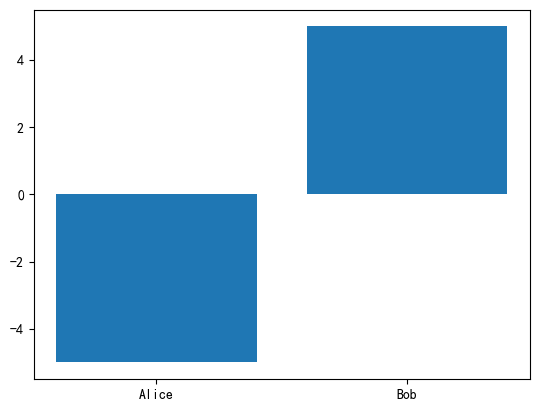

<Figure size 640x480 with 0 Axes>

In [ ]:
import os
import matplotlib.pyplot as plt
os.makedirs(r"D:\jjdsjyrgzn_python\5shangjike", exist_ok=True) 
os.chdir(r"D:\jjdsjyrgzn_python\5shangjike") 
plt.rcParams['font.sans-serif'] = ['SimHei'] # 使用黑体显示中文
plt.rcParams['axes.unicode_minus'] = False # 解决负号显示问题

class GroupAA:
    def __init__(self):
        # 初始化为空字典，没有参与者。
        self.participants = {} 
    def add_participant(self, name):
        # 初始化余额为0.0
        self.participants[name] = 0.0 
    def add_expense(self, payer , amount):
         # 计算每个人应平摊的金额
        share = amount / len(self.participants)
        for p in self.participants:
            self.participants[p] -= share
        self.participants[payer] += amount

    def show_balances(self):
        print("当前每个人的结算情况：")
        for name, balance in self.participants.items():
            # 保留两位小数输出
            print(f"{name}: {balance:.2f}") 
# ========== 使 用 示 例 ==========
group = GroupAA()
group.add_participant("Alice")
group.add_participant("Bob")
group.add_expense("Bob", 10)
group.show_balances()
# 显示当前每个人的结算情况：
# 获取参与者和余额数据
names = list(group.participants.keys())
balances = list(group.participants.values())
# 绘制柱状图
plt.bar(names , balances)
plt.show()
plt.savefig(r"D:\jjdsjyrgzn_python\5shangjike\AA结 算.png") # 保 存 图 表

## 5.2知识点拆解
### 定义类
```py
class GroupAA:
    def __init__(self):
        self.participants = {}
```
- class GroupAA: 表示定义一个类，这个类的名字叫做 GroupAA 。对于 AA 这一类群体，在现实中会有不同的具体实例（对象），比如小红组织的毕业旅行团是 GroupAA这一类的一个对象，小明组织的调研团是 GroupAA 这一类的另一个对象。对于每个对象，只要它属于 GroupAA 这一类，就都可以相应去定义参与 AA 的成员、记账、并且计算 AA 的情况。
-  def ```__init__(self):``` 是 Python 中的构造函数，或者叫做初始化设定。跟我们上节课学的普通函数不同的是，这种构造函数专门用在“定义类”中，把某一类对象做初始化。在今天最简单的情景中，我们先做最简单的初始化，不增加任何额外的要求和条件；下次深化讲 OOP 的时候，我们会把初始化做得复杂一点。今天，你只要能敲下来这行代码，就很成功了！
-  self.participants = {} ：创建一个空字典，用来存储“参与者姓名”和这个人的“余额”。

### 添加参加者
```py
def add_participant(self, name):
    self.participants[name] = 0.0
```
-  对于某个特定的 AA 群体（GroupAA 类别中的特定对象），一个基本操作是“添加参与者”，现在我们要定义这个操作。
- 因为GroupAA是类名，不是具体的对象。用类名去调用方法时，Python就不会自动传self 了,如果非要用类名去调用，就必须把参数全写满，手动把对象传进去,例如：
```GroupAA.show_balances(group)```
 这样就没问题，但麻烦,一般不这么写。
-  将name 作为键放入字典 self.participants 中，默认值0.0 代表其“初始余额为零”，或者说每个人加入 AA 群体时，还没有开始垫钱，在后续旅行过程中，出现了花销再做相应的记账，所以加入的余额时都设置为零。
### 创建实例并应用 GroupAA
- 使用对象.方法() 这种语法结构时，Python会自动把点号前面的那个对象（也就是 group），作为第一个参数塞进去，精准地对号入座赋值给self。
```py
# 创建一个GroupAA对象表示一个AA制结算群体
group = GroupAA()
# 添加所有参与者：Alice、Bob
group.add_participant("Alice")
group.add_participant("Bob")
# 记录Bob垫付了10元，Alice没有垫付
group.add_expense("Bob", 10)
# 查看每个人的余额（应收或应付情况）
group.show_balances()
# 此时A要付给Bob5 元，所以A是 -5，而Bob是+5。
```